In [94]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.nn.utils import parametrize

import matplotlib.pyplot as plt

In [2]:
# Simulation parameters
I_0 = 1e2  # Assume uniform blank scan
n_dimensions = 300
m_dimensions = 400
k_dimensions = 5

def generate_data():
    # Generate nonnegative matrices
    data_A = torch.rand((n_dimensions, k_dimensions))
    data_B = torch.rand((k_dimensions, m_dimensions))

    # Normalize A
    data_A = data_A / torch.sum(data_A, dim=1, keepdim=True)

    # Compute matrix product
    data_Z = data_A @ data_B

    # Generate Poisson data
    rate = I_0 * torch.exp(-data_Z)
    data_I = torch.distributions.Poisson(rate).sample()
    # data_I = rate

    return data_A, data_B, data_Z, data_I

In [3]:
def plot_matrix(ax, data, title, cmap="gray", vmin=None, vmax=None):
    out = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    return out

def plot_matrix_rows(ax, data, title):
    for i, row in enumerate(data):
        ax.plot(i + row)
    ax.set_title(title)

In [4]:
# Define parametrization functions
class Nonnegative(nn.Module):
    def forward(self, eta):
        return torch.maximum(torch.tensor(0.0), eta)

    def right_inverse(self, x):
        return x

class NonnegativeRowSums(nn.Module):
    def forward(self, eta):
        eta = torch.maximum(torch.tensor(0.0), eta)
        return eta / torch.sum(eta, dim=1, keepdim=True)

    def right_inverse(self, x):
        return x

# Define class for constrained optimization
class NonnegativeAttenuationLoss(nn.Module):
    def __init__(self, shape):
        super().__init__()
        n_dimensions, k_dimensions, m_dimensions = shape

        # Initialize matrices randomly
        A = torch.rand((n_dimensions, k_dimensions))
        B = torch.rand((k_dimensions, m_dimensions))

        # Make matrices parameters so they are optimized by Pytorch
        self.A = nn.Parameter(A)
        self.B = nn.Parameter(B)

        # Add nonnegative parametrization
        # parametrize.register_parametrization(self, "A", NonnegativeRowSums())
        # parametrize.register_parametrization(self, "B", Nonnegative())

    def forward(self, I):
        # Compute negative log likelihood
        T = I / I_0
        Z = torch.matmul(self.A, self.B)
        return torch.sum(torch.exp(-Z) + T * Z)

# Optimization function
# TODO Use dataloader (returns rows of Z) to fit subset of pixels
def train_model(model, data_I, n_iterations=100, lr=0.1, plot_loss=False):
    # We initialize an optimizer for the model parameters
    # optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    # We take n_iterations steps of gradient descent
    losses = []
    for _ in range(n_iterations):
        optimizer.zero_grad()
        loss = model(data_I)
        loss.backward()
        optimizer.step()

        model.A.data = torch.maximum(torch.tensor(0.0), model.A.data)
        model.B.data = torch.maximum(torch.tensor(0.0), model.B.data)

        losses.append(torch.log(loss).detach())

    if plot_loss:
        plt.figure(figsize=(4, 3))
        plt.plot(losses)
        plt.xlabel("Iterations")
        plt.ylabel("Log Loss")

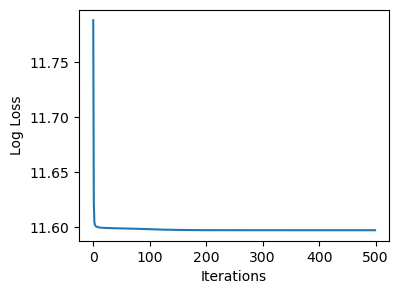

In [5]:
residuals = np.array([])
plot_loss = True
for _ in range(100):
    # Generate data
    data_A, data_B, data_Z, data_I = generate_data()

    # Initialize the model
    model_nnal = NonnegativeAttenuationLoss((n_dimensions, k_dimensions, m_dimensions))

    # # Overwrite the initial parameters with the true values
    # with torch.no_grad():
    #     model_nnal.A.copy_(data_A)
    #     model_nnal.B.copy_(data_B)

    # Fit the model
    train_model(model_nnal, data_I, n_iterations=500, lr=0.005, plot_loss=plot_loss)
    plot_loss = False
    A_nnal = model_nnal.A.detach()
    B_nnal = model_nnal.B.detach()
    Z_nnal = A_nnal @ B_nnal
    Z_res = Z_nnal - data_Z
    residuals = np.append(residuals, Z_res.norm() / data_Z.norm())

Text(0.5, 1.0, 'Relative error of NNAL reconstruction')

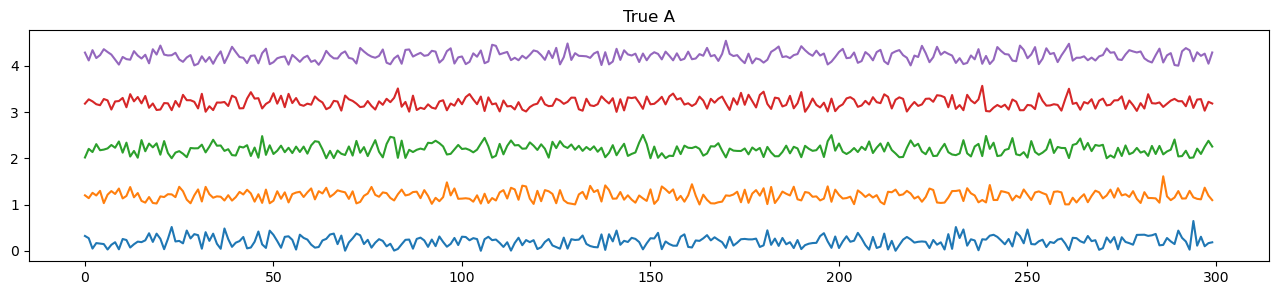

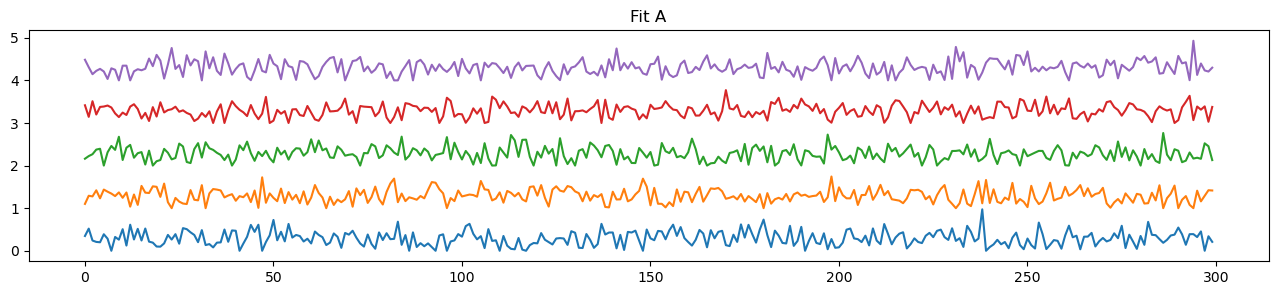

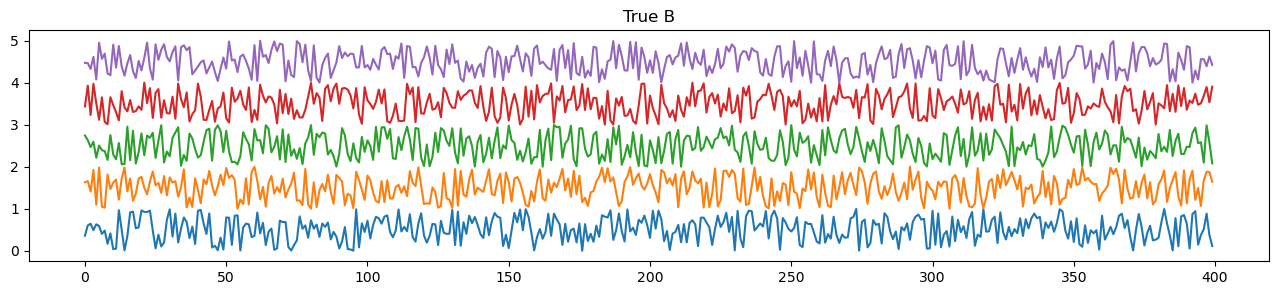

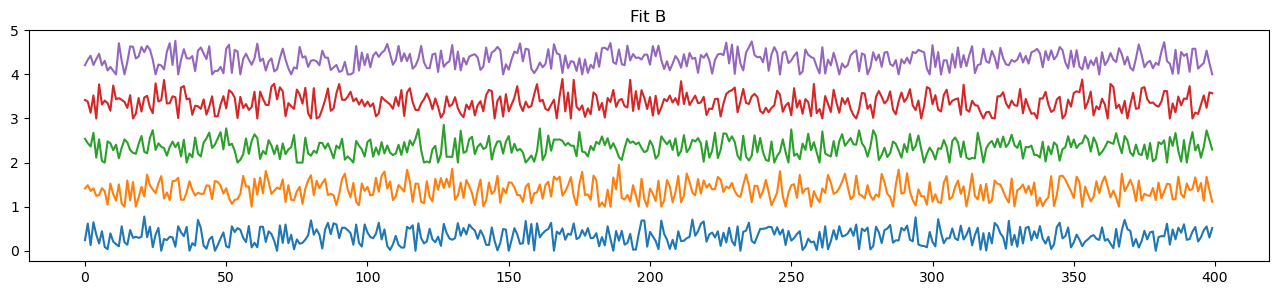

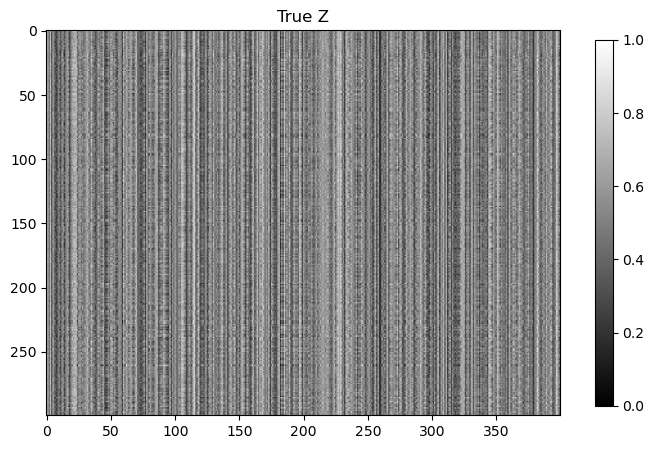

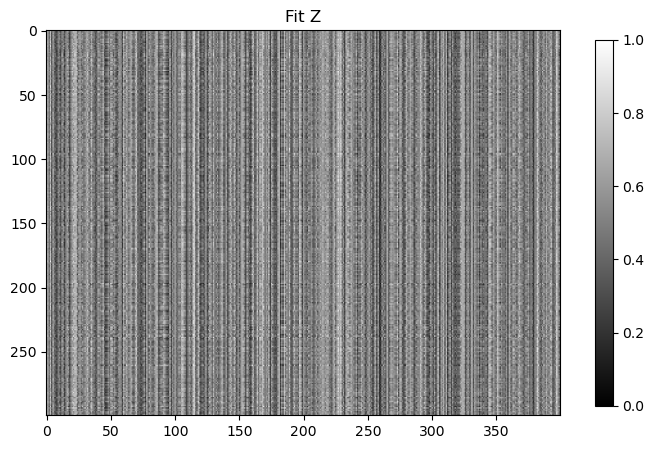

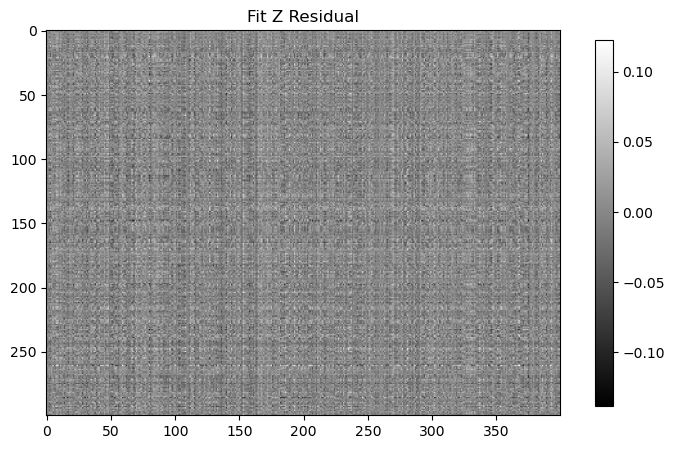

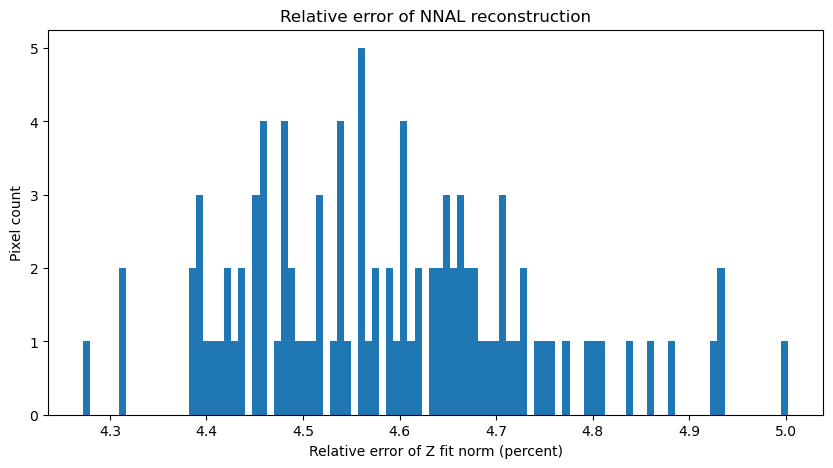

In [6]:
# Visualize the matrices learned by the model
fig, ax = plt.subplots(figsize=(16, 3))
plot_matrix_rows(ax, data_A.T, "True A")
fig, ax = plt.subplots(figsize=(16, 3))
plot_matrix_rows(ax, A_nnal.T, "Fit A")
fig, ax = plt.subplots(figsize=(16, 3))
plot_matrix_rows(ax, data_B, "True B")
fig, ax = plt.subplots(figsize=(16, 3))
plot_matrix_rows(ax, B_nnal, "Fit B")
fig, ax = plt.subplots(figsize=(9, 5))
im = plot_matrix(ax, data_Z, "True Z", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.95)
fig, ax = plt.subplots(figsize=(9, 5))
im = plot_matrix(ax, Z_nnal, "Fit Z", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.95)
fig, ax = plt.subplots(figsize=(9, 5))
im = plot_matrix(ax, Z_res, "Fit Z Residual")
plt.colorbar(im, ax=ax, shrink=0.95)

plt.figure(figsize=(10,5))
plt.hist(100 * residuals, bins=100)
# plt.yscale("log")
plt.xlabel("Relative error of Z fit norm (percent)")
plt.ylabel("Pixel count")
plt.title("Relative error of NNAL reconstruction")